# Tank Model Setup: Hydrostratigraphy and Boundary Conditions

This notebook loads and visualizes the physical setup of a laboratory flow tank, including its hydrostratigraphic structure and the locations of internal boundary conditions (constant head cells and well screens).

The tank is **124 cm wide** and **50 cm tall**, discretized into a uniform grid. Two input matrices are used:

- **`tank_hydrostrat.txt`** — defines the hydrostratigraphic units across the tank grid
  - `0` = out of model bounds
  - `1` = 'sand'
  - `2` = 'gravel'
  - `3` = 'clay'
- **`tank_heads_and_wells.txt`** — defines boundary condition locations, where:
  - `1` = constant head or drain cell
  - `2` = well screen location

This notebook shows how to load this data and calculate grid cell dimensions that are derived directly from the matrix size relative to the physical tank dimensions. There is a cell to produce a three-panel figure showing the boundary condition matrix, the hydrostratigraphy, and an overlay of the two — providing an overview of the tank configuration for parameterizing the flow and transport simulations in MODFLOW.

This data was segmented thanks to Sam Kershner.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# load tank hydrostratigraphy
hydrostrat = np.loadtxt(r"tank_hydrostrat.txt")
print("Hydrostrat matrix dimensions (row, col):")
print(np.shape(hydrostrat))
# load tank wells (=2) and constant head locations (=1)
heads_wells = np.loadtxt(r"tank_heads_and_wells.txt")
print("Well location matrix dimensions (row, col):")
print(heads_wells.shape)

# determine matrix dimensions
nrows, ncols = heads_wells.shape
grid_cell_width = 124/ncols # width of tank in cm
grid_cell_height = 50/nrows # width of tank in cm

print("-" * 25)
print("grid cell width = " + str(grid_cell_width) + " cm")
print("grid cell height = " + str(grid_cell_height) + " cm")


well_rows, well_cols = np.where(heads_wells == 2)
print("-" * 25)
print("Well locations (row, col):")
print("-" * 25)
for r, c in zip(well_rows, well_cols):
    print(f"  Row: {r}, Col: {c}")

Hydrostrat matrix dimensions (row, col):
(295, 593)
Well location matrix dimensions (row, col):
(295, 593)
-------------------------
grid cell width = 0.209106239460371 cm
grid cell height = 0.1694915254237288 cm
-------------------------
Well locations (row, col):
-------------------------
  Row: 75, Col: 273
  Row: 79, Col: 558
  Row: 82, Col: 457
  Row: 95, Col: 120
  Row: 121, Col: 401
  Row: 123, Col: 174
  Row: 123, Col: 286
  Row: 125, Col: 32
  Row: 134, Col: 564
  Row: 151, Col: 473
  Row: 152, Col: 243
  Row: 173, Col: 407
  Row: 175, Col: 28
  Row: 177, Col: 168
  Row: 215, Col: 492
  Row: 223, Col: 105
  Row: 223, Col: 224
  Row: 236, Col: 568
  Row: 239, Col: 414
  Row: 240, Col: 23
  Row: 240, Col: 162
  Row: 272, Col: 207
  Row: 282, Col: 575
  Row: 287, Col: 156
  Row: 287, Col: 282
  Row: 287, Col: 420
  Row: 290, Col: 18
  Row: 290, Col: 317


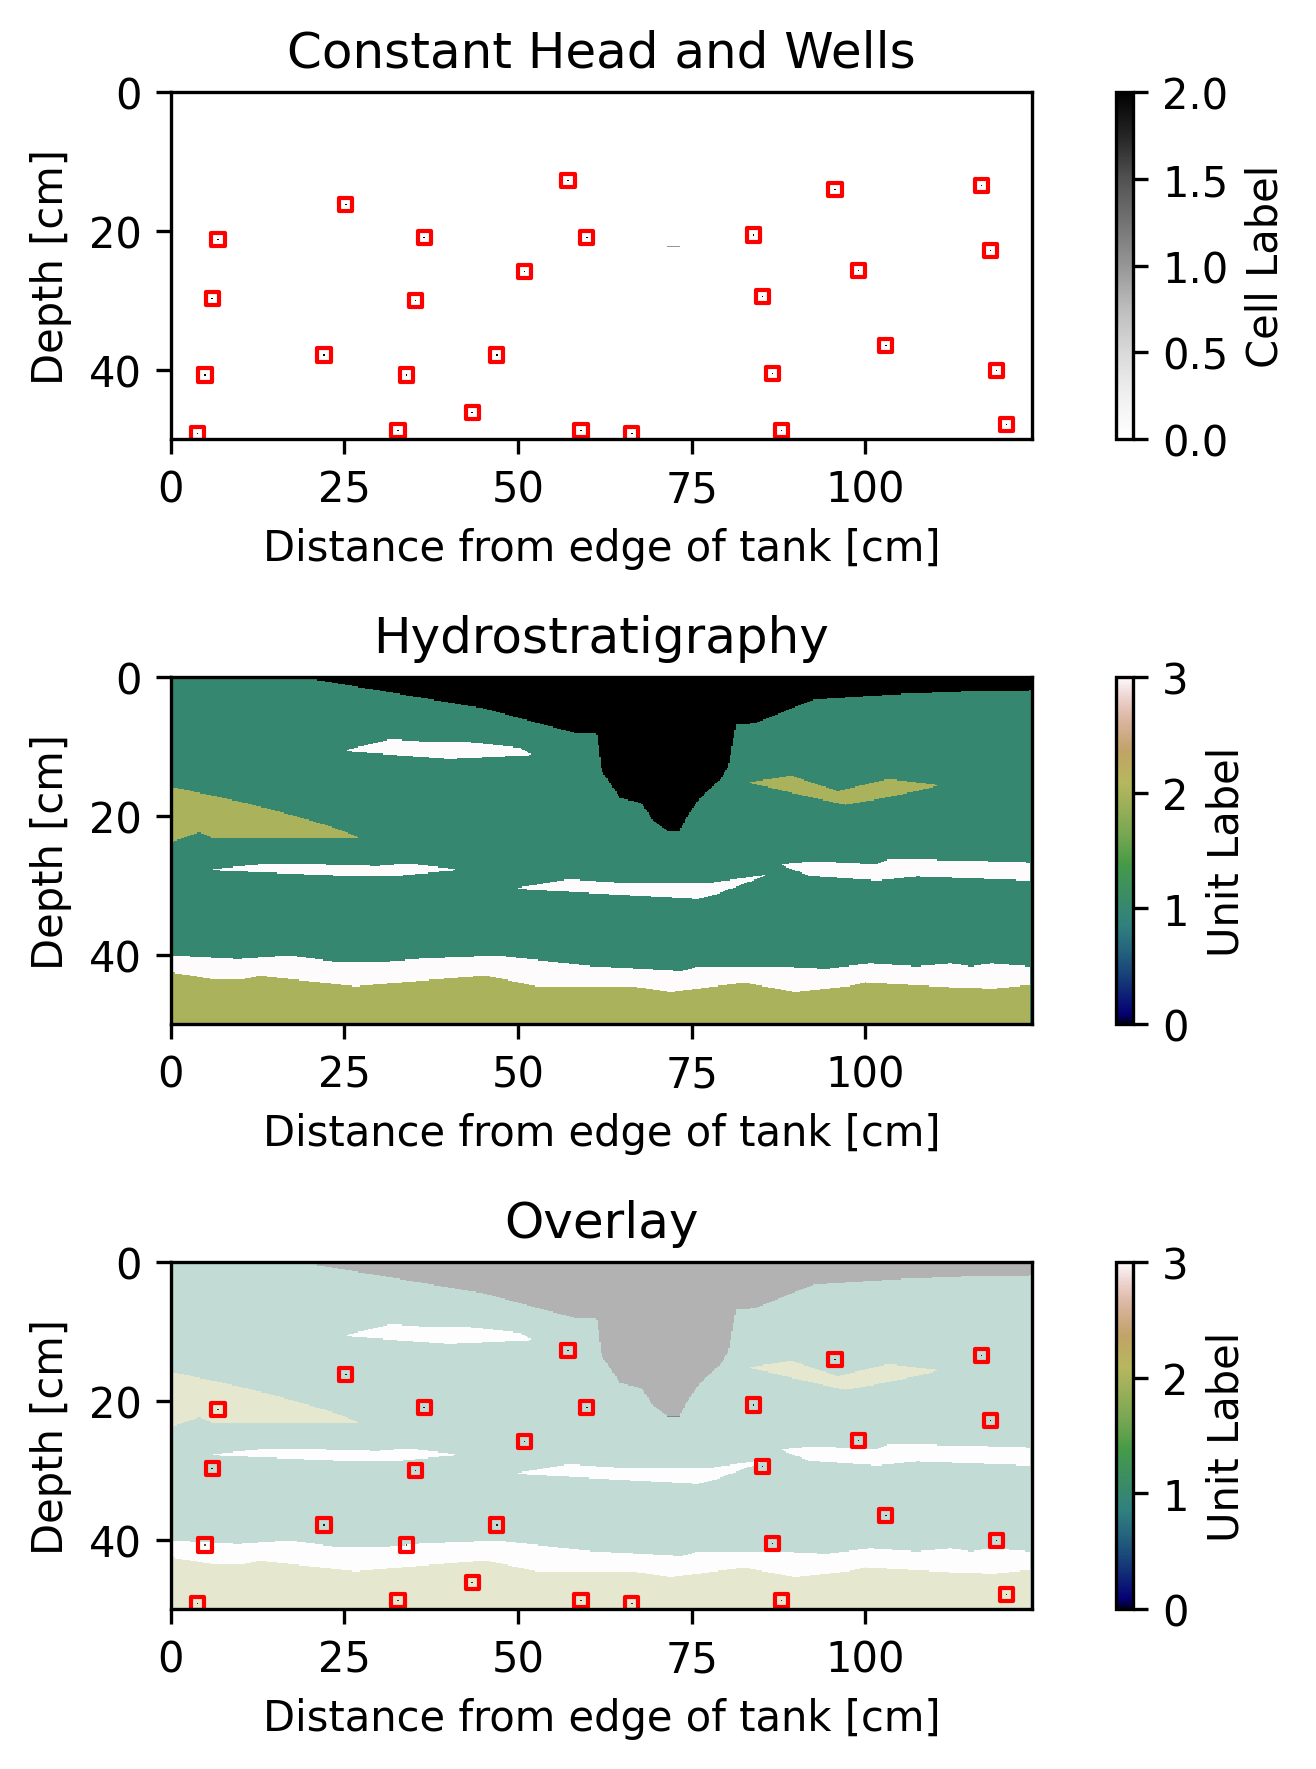

In [31]:
# Define grid
x = np.arange(ncols + 1) * grid_cell_width
y = np.arange(nrows + 1) * grid_cell_height

# Highlight wells and define x-y locations
well_rows, well_cols = np.where(heads_wells == 2)
well_x = (well_cols + 0.5) * grid_cell_width
well_y = (well_rows + 0.5) * grid_cell_height

fig, axes = plt.subplots(3, 1, figsize=(6, 6), dpi=300)
# Top: heads and wells matrix (1 = constant head or drain, 2 = well screen location)
c1 = axes[0].pcolormesh(x, y, heads_wells, cmap="Greys")
# Highlight wells with red markers
axes[0].scatter(well_x, well_y, s=10, marker="s", facecolors="none", edgecolors="red", linewidths=1, label="Wells")
plt.colorbar(c1, ax=axes[0], label="Cell Label")
axes[0].set_title("Constant Head and Wells")
axes[0].set_xlabel("Distance from edge of tank [cm]")
axes[0].set_ylabel("Depth [cm]")
axes[0].set_aspect("equal")
axes[0].invert_yaxis()

# Middle: hydrostrat
c2 = axes[1].pcolormesh(x, y, hydrostrat, cmap="gist_earth")
plt.colorbar(c2, ax=axes[1], label="Unit Label")
axes[1].set_title("Hydrostratigraphy")
axes[1].set_xlabel("Distance from edge of tank [cm]")
axes[1].set_ylabel("Depth [cm]")
axes[1].set_aspect("equal")
axes[1].invert_yaxis()

# Bottom: overlay
c3 = axes[2].pcolormesh(x, y, hydrostrat, cmap="gist_earth")
axes[2].pcolormesh(x, y, heads_wells, cmap="Greys", alpha=0.7)
axes[2].scatter(well_x, well_y, s=10, marker="s", facecolors="none", edgecolors="red", linewidths=1, label="Wells")
plt.colorbar(c3, ax=axes[2], label="Unit Label")
axes[2].set_title("Overlay")
axes[2].set_xlabel("Distance from edge of tank [cm]")
axes[2].set_ylabel("Depth [cm]")
axes[2].set_aspect("equal")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

